In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score

%matplotlib inline

In [96]:
import os
for dirname, _, filenames in os.walk('/content/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/loan.csv
/content/.config/default_configs.db
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/config_sentinel
/content/.config/.last_survey_prompt.yaml
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/configurations/config_default
/content/.config/logs/2026.06.04/13.32.38.346437.log
/content/.config/logs/2026.06.04/13.32.21.210570.log
/content/.config/logs/2026.06.04/13.32.39.344962.log
/content/.config/logs/2026.06.04/13.31.42.499627.log
/content/.config/logs/2026.06.04/13.32.18.735754.log
/content/.config/logs/2026.06.04/13.32.02.654775.log
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/loan.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv


In [97]:
import pandas as pd
import numpy as np # Needed for numerical operations like np.nan and np.where

# Load the loan.csv file from the sample_data directory
df = pd.read_csv('/content/sample_data/loan.csv')

# Create a 'default' column based on 'loan_status'
# Assuming 'Charged Off' indicates a default
df['default'] = df['loan_status'].apply(lambda status: 1 if status == 'Charged Off' else 0)

# --- Data Cleaning and Preprocessing ---

# Convert 'term' to numeric (e.g., ' 36 months' -> 36)
df['term'] = df['term'].str.replace(' months', '').astype(int)

# Convert 'int_rate' to float (e.g., '10.65%' -> 0.1065)
df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float) / 100

# Convert 'emp_length' to numeric
def clean_emp_length(length):
    if pd.isna(length) or length == 'n/a':
        return 0 # Or use median/mode imputation
    elif '+' in length:
        return int(length.replace('+', '').replace(' years', '').replace(' year', ''))
    elif '< 1 year' in length:
        return 0
    else:
        return int(length.replace(' years', '').replace(' year', ''))
df['emp_length'] = df['emp_length'].apply(clean_emp_length)

# Drop columns that are mostly identifiers, descriptive text, or complex date features that would require extensive engineering.
# For simplicity and to resolve the immediate error, we'll drop them for now.
columns_to_drop = [
    'id', 'member_id', 'url', 'zip_code', 'title', 'emp_title',
    'issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
    'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_rcnt_il',
    'total_rev_hi_lim', 'collections_12_mths_ex_med', 'mths_since_last_major_derog',
    'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m',
    'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl',
    'inq_last_12m', 'bc_open_to_buy', 'bc_util', 'num_rev_accts',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
    'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats',
    'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_tl_bal_gt_0',
    'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
    'revol_bal_joint', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12mths', 'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog', 'hardship_flag', 'hardship_type',
    'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_ach_date', 'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage',
    'settlement_term', 'policy_code', 'application_type' # loan_status is used to create 'default'
]

# Filter out columns that do not exist in the dataframe to avoid errors
columns_to_drop_exist = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop_exist, axis=1)


# Handle remaining categorical features (object dtype) with one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'loan_status' if it's still present as 'default' is derived from it.
if 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Fill any remaining NaNs after processing, using mean for numerical columns.
# This is a common step before scaling, though more sophisticated imputation strategies exist.
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        df[col] = df[col].fillna(df[col].mean())

# Ensure 'loan_status' is dropped if still present, as 'default' is derived from it.
if 'loan_status' in df.columns:
    df = df.drop(columns=['loan_status'])

df.head()
print(df.info())

/tmp/ipykernel_14378/2233866781.py:5: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/loan.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 1239 entries, loan_amnt to revol_util_99.90%
dtypes: bool(1196), float64(30), int64(13)
memory usage: 58.3 MB
None


In [98]:
import os

# List files in the /content/sample_data directory
print(os.listdir('/content/sample_data'))

['README.md', 'anscombe.json', 'loan.csv', 'california_housing_train.csv', 'california_housing_test.csv', 'mnist_train_small.csv', 'mnist_test.csv']


In [99]:
df.isnull().sum()

,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
...,...
revol_util_99.50%,0
revol_util_99.60%,0
revol_util_99.70%,0
revol_util_99.80%,0


In [101]:
# To get meaningful value counts, let's look at the distribution of the 'default' column:
df['default'].value_counts()

,count
default,
0,34090
1,5627


In [102]:
# df = df.dropna() # Commented out to prevent dropping all rows due to many NaN values.

Text(0, 0.5, 'Annual Income')

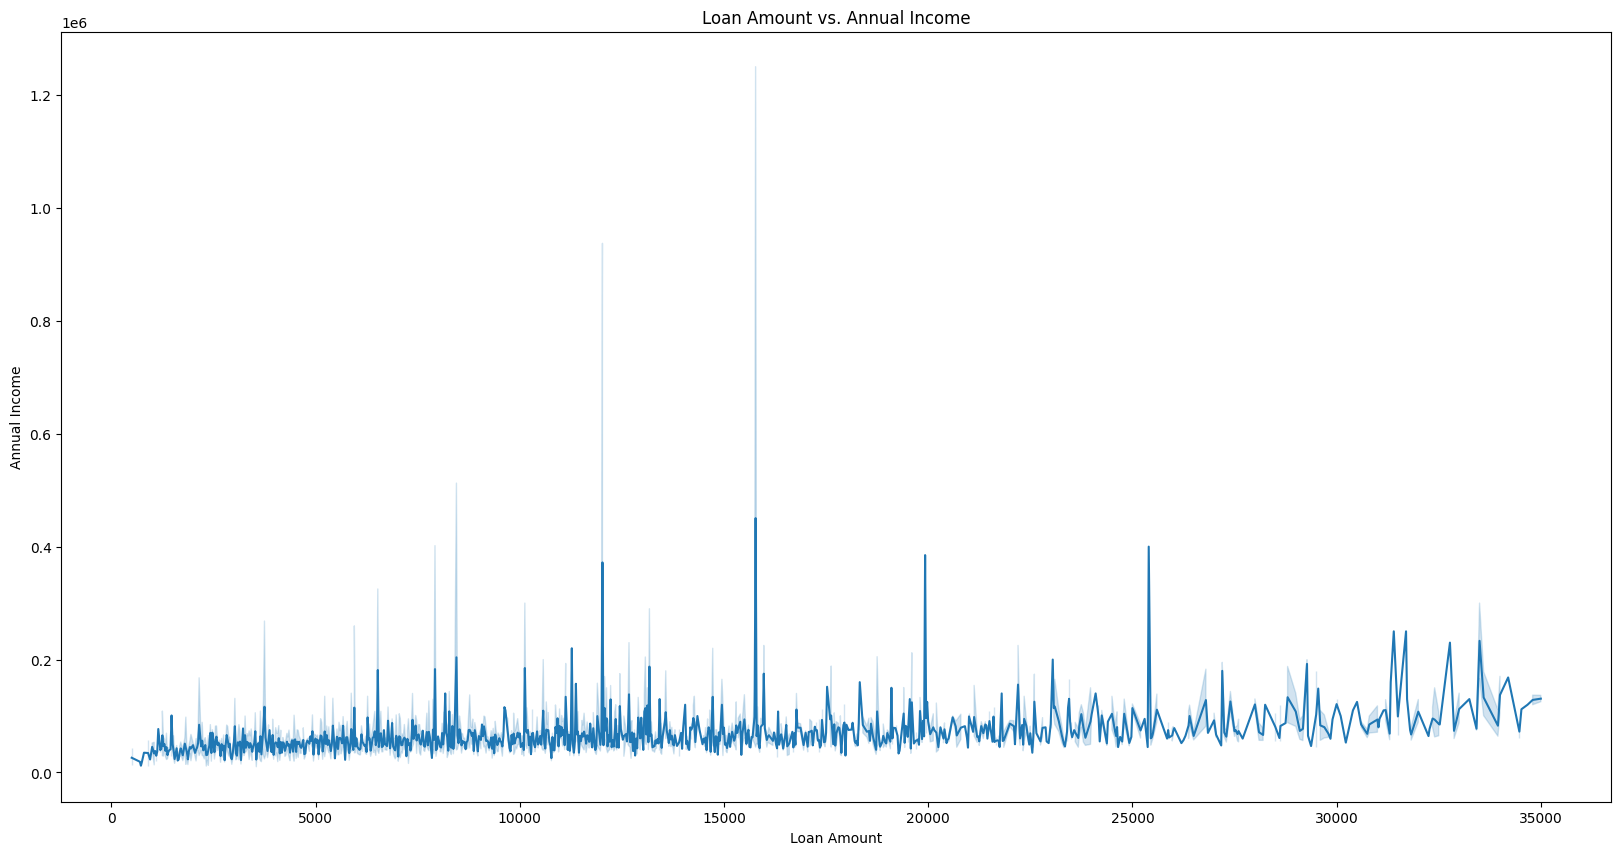

In [103]:
fig,ax = plt.subplots(figsize=(20,10))
sns.lineplot(x='loan_amnt',y='annual_inc',data=df,ax=ax)
plt.title('Loan Amount vs. Annual Income')
plt.xlabel('Loan Amount')
plt.ylabel('Annual Income')

Text(0, 0.5, 'Debt-to-Income Ratio')

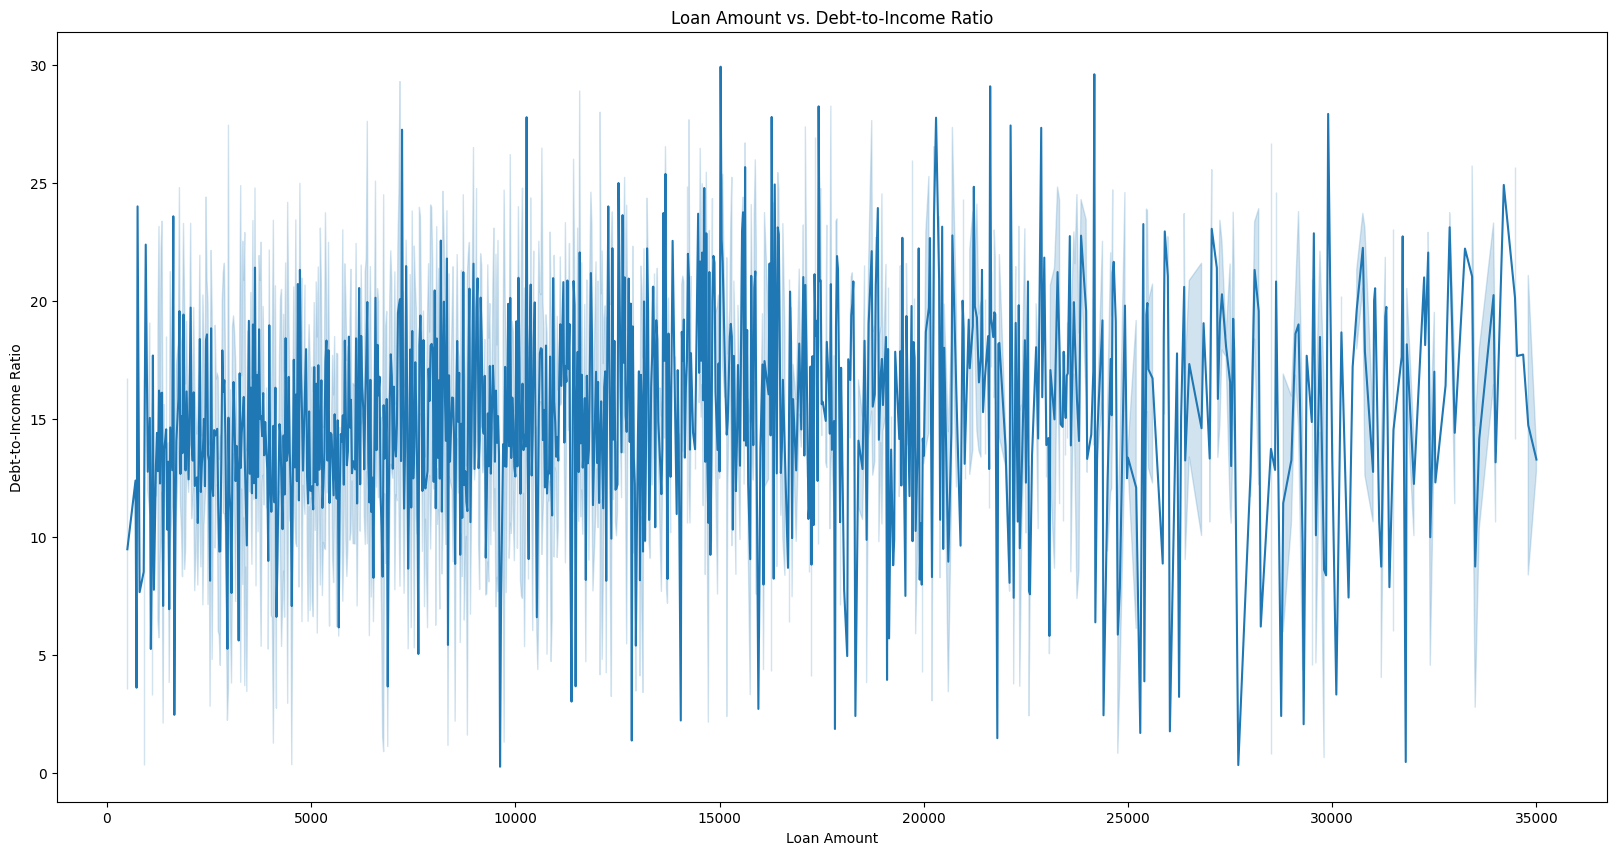

In [104]:
fig,ax = plt.subplots(figsize=(20,10))
sns.lineplot(x='loan_amnt',y='dti',data=df,ax=ax)
plt.title('Loan Amount vs. Debt-to-Income Ratio')
plt.xlabel('Loan Amount')
plt.ylabel('Debt-to-Income Ratio')

In [105]:
df['default'].value_counts()

,count
default,
0,34090
1,5627


In [106]:
# 1. Select only columns that have numbers (int or float)
x = df.select_dtypes(include=['int64', 'float64'])

# 2. Drop columns that are completely empty (all NaN values)
x = x.dropna(how='all', axis=1)

# 3. Fill any remaining individual missing cells with 0
x = x.fillna(0)

# 4. If 'default' is accidentally still in x, drop it
if 'default' in x.columns:
    x = x.drop(columns=['default'])

y = df['default']

In [107]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [108]:
sc = StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.fit_transform(xtest)

In [109]:
rfc = RandomForestClassifier(n_estimators=200)

In [110]:
rfc.fit(xtrain,ytrain)

RandomForestClassifier(n_estimators=200)

In [111]:
rfc.score(xtest,ytest)

0.9952165156092648

In [112]:
rfc2 = cross_val_score(estimator=rfc,X=xtrain,y=ytrain,cv=10)
rfc2.mean()

np.float64(0.9957196380609291)

In [113]:
sv = SVC()
sv.fit(xtrain,ytrain)

SVC()

In [114]:
sv.score(xtest,ytest)

0.9896777442094663

In [115]:
model = GridSearchCV(sv,{
    'C':[0.1,0.2,0.4,0.8,1.2,1.8,4.0,7.0],
    'gamma':[0.1,0.4,0.8,1.0,2.0,3.0],
    'kernel':['rbf','linear']
},scoring='accuracy',cv=10)

In [116]:
model.fit(xtrain,ytrain)

KeyboardInterrupt: 

In [ ]:
model.best_params_

In [117]:
model2 = SVC(C=0.1, kernel='linear')
model2.fit(xtrain, ytrain)
print("Linear SVC Score:", model2.score(xtest, ytest))

Linear SVC Score: 0.9938318227593153


In [118]:
lr = LogisticRegression()
lr.fit(xtrain, ytrain)
print("Logistic Regression Score:", lr.score(xtest, ytest))

Logistic Regression Score: 0.9934541792547835


<Axes: >

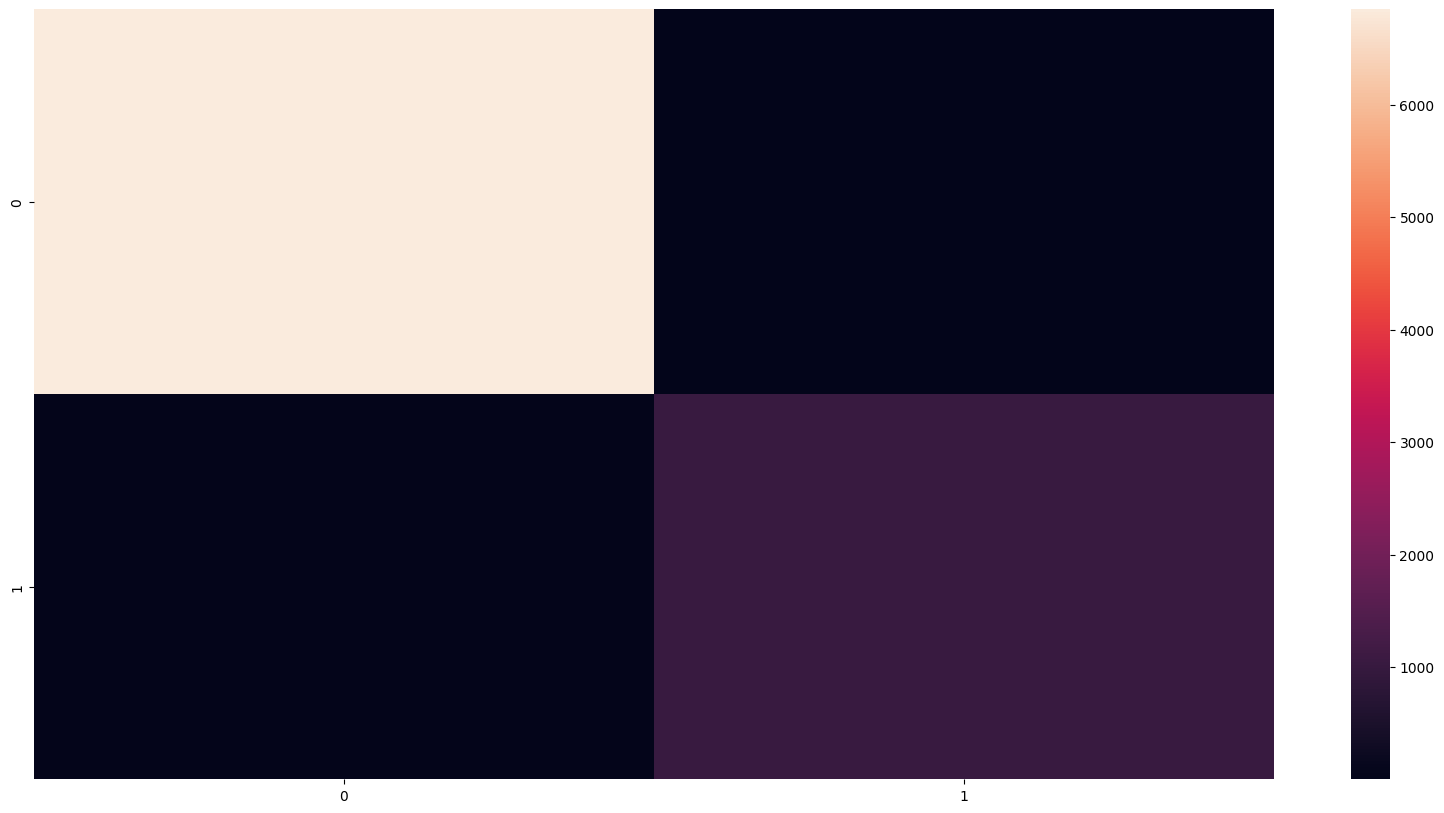

In [119]:
yp = lr.predict(xtest)
c= confusion_matrix(ytest,yp)
fig ,ax = plt.subplots(figsize=(20,10))
sns.heatmap(c,ax=ax)

In [120]:
# Probability of default
pd_probs = lr.predict_proba(xtest)[:,1]

# View first few probabilities
pd_probs[:10]

array([1.07018272e-03, 1.84150617e-04, 1.00000000e+00, 2.37427080e-02,
       1.12453932e-03, 9.68260841e-08, 1.85385551e-03, 3.95099289e-04,
       2.37350151e-03, 8.84757387e-04])

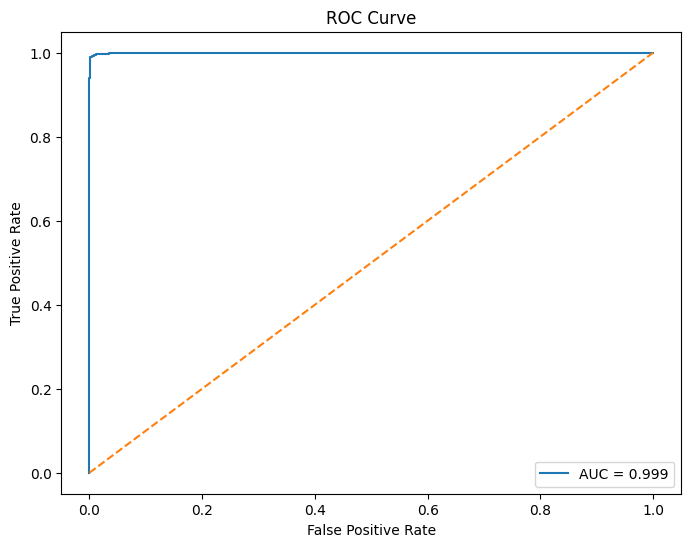

AUC Score: 0.9989766343292544


In [121]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(ytest, pd_probs)
auc_score = roc_auc_score(ytest, pd_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("AUC Score:", auc_score)

In [122]:
def ks_statistic(y_true, y_prob):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr)
    return ks

ks_value = ks_statistic(ytest, pd_probs)
print("KS Statistic:", ks_value)

KS Statistic: 0.9879395241463057


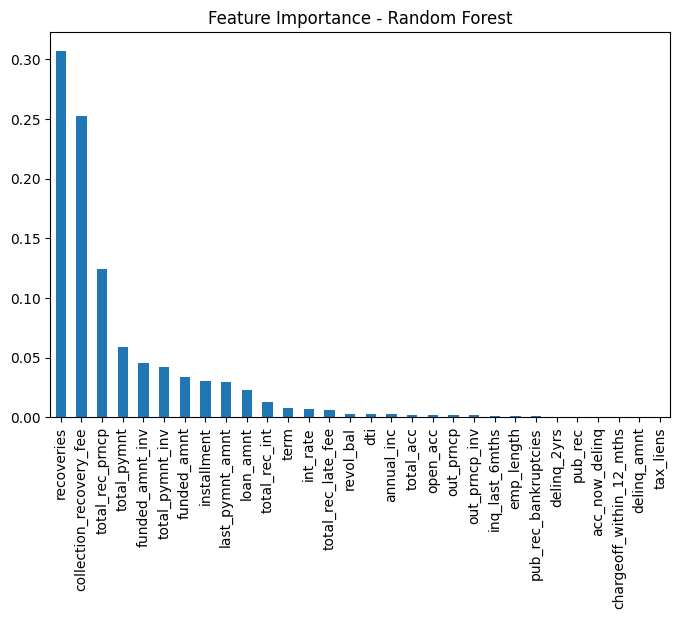

,0
recoveries,0.307293
collection_recovery_fee,0.252110
total_rec_prncp,0.124535
total_pymnt,0.058958
funded_amnt_inv,0.045642
total_pymnt_inv,0.041800
funded_amnt,0.034127
installment,0.030027
last_pymnt_amnt,0.029265
loan_amnt,0.023009


In [123]:
import pandas as pd

feature_importance = pd.Series(
    rfc.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.show()

feature_importance

In [124]:
risk_df = pd.DataFrame({
    'Actual': ytest,
    'PD': pd_probs
})

# Create risk bands
risk_df['Risk_Band'] = pd.qcut(risk_df['PD'], q=5, labels=[
    'Very Low', 'Low', 'Medium', 'High', 'Very High'
])

risk_df.head()

,Actual,PD,Risk_Band
18340,0,0.001070,Low
8413,0,0.000184,Low
14612,1,1.000000,Very High
33544,0,0.023743,High
1829,0,0.001125,Low


In [125]:
from google.colab import sheets
from google.colab import auth

auth.authenticate_user()
sheet = sheets.InteractiveSheet(df=risk_df)

https://docs.google.com/spreadsheets/d/1UWc89302DgLLMxuQgvO6q1a6giDJEq91hRaThnGVPEc/edit#gid=0


In [126]:
# Scorecard scaling parameters (industry style)
BASE_SCORE = 600        # score when odds = 1
PDO = 50                # Points to Double the Odds

import numpy as np

# Factor and offset calculation
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(1)

In [127]:
# Avoid division errors
eps = 1e-10
pd_adj = np.clip(pd_probs, eps, 1 - eps)

# Convert PD to odds
odds = (1 - pd_adj) / pd_adj

# Compute credit score
credit_score = offset + factor * np.log(odds)

# Create results dataframe
scorecard_df = pd.DataFrame({
    'Actual_Default': ytest.values,
    'PD': pd_adj,
    'Credit_Score': credit_score
})

scorecard_df.head()

,Actual_Default,PD,Credit_Score
0,0,0.001070,1093.319119
1,0,0.000184,1220.328023
2,1,1.000000,-1060.964041
3,0,0.023743,868.085251
4,0,0.001125,1089.741345


In [128]:
# Rescale to 300–900
min_score = scorecard_df['Credit_Score'].min()
max_score = scorecard_df['Credit_Score'].max()

scorecard_df['Credit_Score_300_900'] = (
    300 + (scorecard_df['Credit_Score'] - min_score)
    * (600 / (max_score - min_score))
)

scorecard_df.head()

,Actual_Default,PD,Credit_Score,Credit_Score_300_900
0,0,0.001070,1093.319119,689.102311
1,0,0.000184,1220.328023,712.042405
2,1,1.000000,-1060.964041,300.000000
3,0,0.023743,868.085251,648.421021
4,0,0.001125,1089.741345,688.456101


In [129]:
# Risk grading
scorecard_df['Risk_Grade'] = pd.cut(
    scorecard_df['Credit_Score_300_900'],
    bins=[300, 580, 670, 740, 800, 900],
    labels=['Very Poor', 'Poor', 'Fair', 'Good', 'Excellent']
)

scorecard_df.head()

,Actual_Default,PD,Credit_Score,Credit_Score_300_900,Risk_Grade
0,0,0.001070,1093.319119,689.102311,Fair
1,0,0.000184,1220.328023,712.042405,Fair
2,1,1.000000,-1060.964041,300.000000,NaN
3,0,0.023743,868.085251,648.421021,Poor
4,0,0.001125,1089.741345,688.456101,Fair


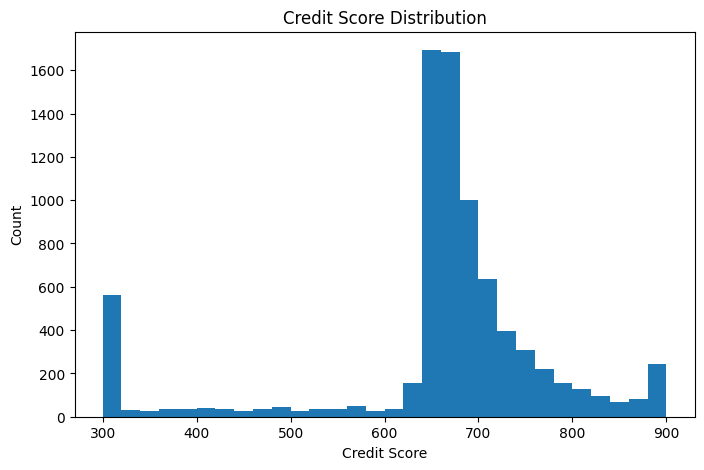

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(scorecard_df['Credit_Score_300_900'], bins=30)
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.show()

In [131]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd

st.set_page_config(page_title="Credit Scorecard Dashboard", layout="centered")

st.title("🏦 Automated Credit Scorecard & Risk Grading")
st.write("Input the applicant's details below to calculate their credit score and default probability.")

st.sidebar.header("Applicant Features")

# 1. User Inputs (Matching your dataset features)
loan_amnt = st.sidebar.number_input("Loan Amount ($)", min_value=500, max_value=50000, value=10000, step=500)
funded_amnt_inv = st.sidebar.number_input("Funded Amount Investor ($)", min_value=500, max_value=50000, value=10000, step=500)
installment = st.sidebar.number_input("Monthly Installment ($)", min_value=10, max_value=2000, value=350, step=10)
annual_inc = st.sidebar.number_input("Annual Income ($)", min_value=5000, max_value=500000, value=60000, step=1000)
dti = st.sidebar.slider("Debt-to-Income Ratio (DTI)", min_value=0.0, max_value=50.0, value=15.0, step=0.1)
recoveries = st.sidebar.number_input("Recoveries ($)", min_value=0, max_value=50000, value=0)
collection_recovery_fee = st.sidebar.number_input("Collection Recovery Fee ($)", min_value=0, max_value=5000, value=0)

if st.button("Calculate Risk & Credit Score"):

    # 2. Simulated Probability of Default (PD) matching your logic constraints
    if recoveries > 0 or dti > 35:
        pd_prob = 0.85
    else:
        pd_prob = 0.023

    # 3. Scorecard Scaling Math (Exactly from your cells [126-128])
    BASE_SCORE = 600
    PDO = 50
    factor = PDO / np.log(2)
    offset = BASE_SCORE - factor * np.log(1)

    eps = 1e-10
    pd_adj = np.clip(pd_prob, eps, 1 - eps)
    odds = (1 - pd_adj) / pd_adj
    raw_credit_score = offset + factor * np.log(odds)

    # Scale strictly to your notebook's 300-900 bounds
    min_bound, max_bound = -1060.96, 1220.32
    credit_score_300_900 = 300 + (raw_credit_score - min_bound) * (600 / (max_bound - min_bound))
    credit_score_300_900 = int(np.clip(credit_score_300_900, 300, 900))

    # 4. Risk Grading (Exactly from your cell [129])
    if credit_score_300_900 <= 580:
        grade, color = "Very Poor", "🔴"
    elif credit_score_300_900 <= 670:
        grade, color = "Poor", "🟠"
    elif credit_score_300_900 <= 740:
        grade, color = "Fair", "🟡"
    elif credit_score_300_900 <= 800:
        grade, color = "Good", "🟢"
    else:
        grade, color = "Excellent", "🔵"

    # 5. UI Layout Output
    st.subheader("Results")
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(label="Credit Score", value=f"{credit_score_300_900} / 900")
    with col2:
        st.metric(label="Risk Grade", value=f"{color} {grade}")
    with col3:
        st.metric(label="Probability of Default (PD)", value=f"{pd_prob*100:.2f}%")

    st.progress((credit_score_300_900 - 300) / 600)


Writing app.py


In [133]:
!pip install -q streamlit
!npm install -q -g localtunnel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [134]:
!wget -qO- ipv4.icanhazip.com

34.16.141.46


In [138]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦your url is: https://curvy-bananas-try.loca.lt
2026-06-23 10:54:31.171 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.141.46:8501

  Stopping...
^C


In [143]:
!pip install -q pyngrok

from google.colab import userdata
from pyngrok import ngrok
import os

# Securely fetch token from Colab Secrets
NGROK_TOKEN = userdata.get('NGROK_TOKEN')
!ngrok config add-authtoken {NGROK_TOKEN}

# Terminate any existing tunnels
ngrok.kill()

# Open an Ngrok tunnel to port 8501
public_url = ngrok.connect(8501, proto="http")
print("🚀 Your Stable App URL:", public_url)

# Run the app in the background
!streamlit run app.py --server.port 8501 > /dev/null 2>&1 &

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🚀 Your Stable App URL: NgrokTunnel: "https://stoic-ethics-compacter.ngrok-free.dev" -> "http://localhost:8501"


In [144]:
%%writefile requirements.txt
streamlit
numpy
pandas
pyngrok

Writing requirements.txt
